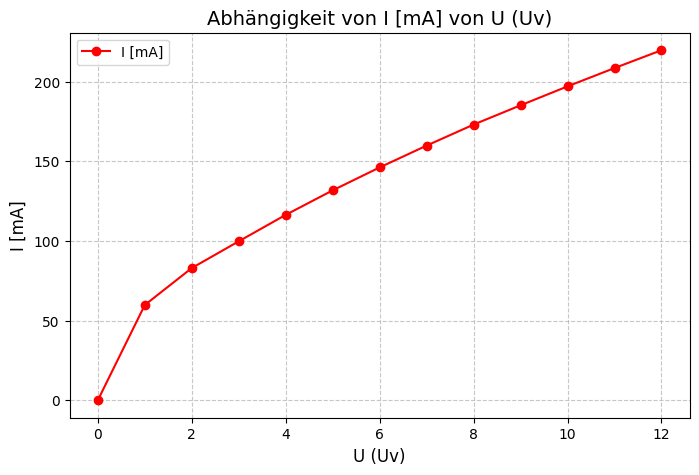

In [13]:
import matplotlib.pyplot as plt

# Daten aus der Tabelle
uv = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
i_ma = [0, 59.8, 83, 99.8, 116.4, 131.8, 146.2, 159.9, 173.1, 185.2, 197.1, 208.6, 219.8]

# Diagramm erstellen
plt.figure(figsize=(8, 5))
plt.plot(uv, i_ma, marker='o', linestyle='-', color='r', label='I [mA]')

# Titel und Achsenbeschriftung hinzufügen
plt.title('Abhängigkeit von I [mA] von U (Uv)', fontsize=14)
plt.xlabel('U (Uv)', fontsize=12)
plt.ylabel('I [mA]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)

# Diagramm anzeigen
plt.show()




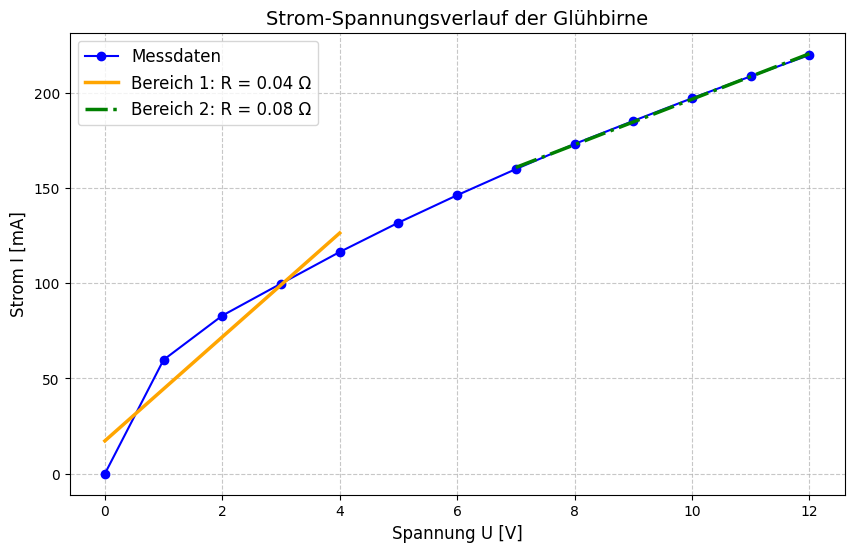

Widerstand im Bereich 1: R1 = 0.04 Ω
Widerstand im Bereich 2: R2 = 0.08 Ω


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Messdaten
uv = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])  # Spannung (U)
i_ma = np.array([0, 59.8, 83, 99.8, 116.4, 131.8, 146.2, 159.9, 173.1, 185.2, 197.1, 208.6, 219.8])  # Strom (I)

# Bereich 1: Erste 5 Punkte
x1 = uv[:5]
y1 = i_ma[:5]
fit1 = np.polyfit(x1, y1, 1)  # lineare Näherung
r1 = 1 / fit1[0]  # Widerstand (Kehrwert der Steigung)

# Bereich 2: Letzte 5 Punkte
x2 = uv[7:]
y2 = i_ma[7:]
fit2 = np.polyfit(x2, y2, 1)  # lineare Näherung
r2 = 1 / fit2[0]  # Widerstand (Kehrwert der Steigung)

# Diagramm erstellen
plt.figure(figsize=(10, 6))
plt.plot(uv, i_ma, 'o-', label='Messdaten', color='blue')
plt.plot(x1, np.polyval(fit1, x1), linestyle='-', linewidth=2.5, label=f'Bereich 1: R = {r1:.2f} Ω', color='orange')
plt.plot(x2, np.polyval(fit2, x2), linestyle='-.', linewidth=2.5, label=f'Bereich 2: R = {r2:.2f} Ω', color='green')

# Titel und Achsenbeschriftung
plt.title('Strom-Spannungsverlauf der Glühbirne', fontsize=14)
plt.xlabel('Spannung U [V]', fontsize=12)
plt.ylabel('Strom I [mA]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.show()


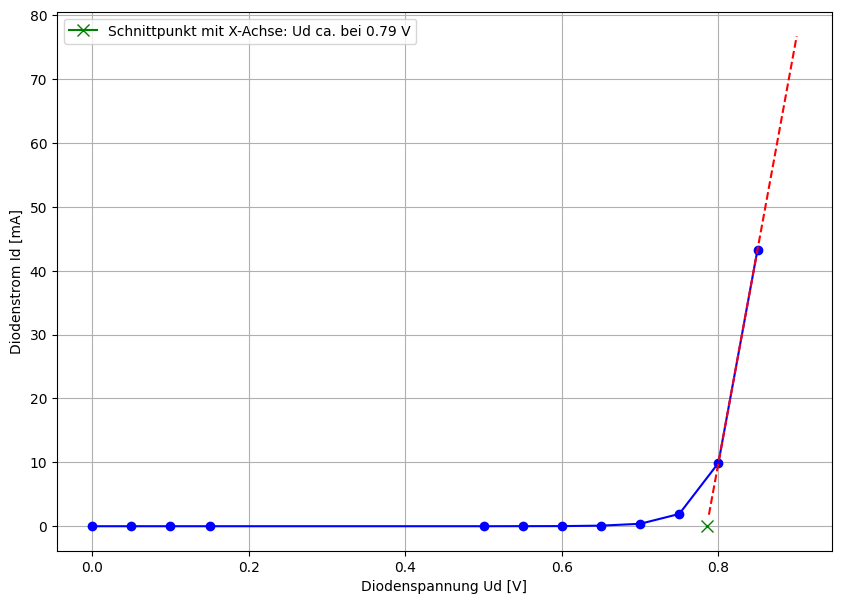

Parameter der linearen Näherung:
Steigung (m): 668.00 mA/V
Y-Achsenabschnitt (a): -524.50 mA
Schnittpunkt mit der X-Achse (ungefähr): 0.785 V


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Neue Daten aus der Tabelle
Ud_original = [0, 0.05, 0.1, 0.15, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85]
Id_mA_original = [0, 0, 0, 0, 0, 0.01, 0.02, 0.09, 0.38, 1.92, 9.9, 43.3]

# Auswahl von zwei Punkten für die lineare Näherung im Durchlassbereich
Ud_linear_fit = Ud_original[-2:]
Id_mA_linear_fit = Id_mA_original[-2:]

# Berechnung der Steigung (m)
m = (Id_mA_linear_fit[1] - Id_mA_linear_fit[0]) / (Ud_linear_fit[1] - Ud_linear_fit[0])

# Berechnung des y-Achsenabschnitts (a)
a = Id_mA_linear_fit[0] - m * Ud_linear_fit[0]

# Erstellen von Punkten für die lineare Näherung im relevanten Spannungsbereich
Ud_linear_plot = np.linspace(0.6, 0.9, 100) # Spannungsbereich für die Gerade
Id_mA_linear_plot_full = a + m * Ud_linear_plot

# Filtern der Punkte, um nur positive oder Null Stromwerte zu behalten
positive_indices = Id_mA_linear_plot_full >= 0
Ud_linear_plot_positive = Ud_linear_plot[positive_indices]
Id_mA_linear_plot_positive = Id_mA_linear_plot_full[positive_indices]

# Schnittpunkt mit der x-Achse (wird nur geplottet, wenn er im angezeigten Bereich liegt)
Ud_schnittpunkt = -a / m

# Erstellen des Plots
plt.figure(figsize=(10, 7))

# Plot der ursprünglichen Kennlinie
plt.plot(Ud_original, Id_mA_original, marker='o', linestyle='-', color='blue')

# Plot der linearen Näherung (nur für positive Stromwerte)
plt.plot(Ud_linear_plot_positive, Id_mA_linear_plot_positive, linestyle='--', color='red')

# Markierung des Schnittpunkts mit der x-Achse, falls sinnvoll
if Ud_schnittpunkt >= Ud_linear_plot.min() and Ud_schnittpunkt <= Ud_linear_plot.max() and a < 0:
    plt.plot(Ud_schnittpunkt, 0, marker='x', color='green', markersize=8, label=f'Schnittpunkt mit X-Achse: Ud ca. bei {Ud_schnittpunkt:.2f} V')

# Beschriftung der Achsen und des Titels
plt.xlabel('Diodenspannung Ud [V]')
plt.ylabel('Diodenstrom Id [mA]')

# Gitternetz hinzufügen
plt.grid(True)

# Legende anzeigen
plt.legend()

# Darstellung des Plots
plt.show()

print(f"Parameter der linearen Näherung:")
print(f"Steigung (m): {m:.2f} mA/V")
print(f"Y-Achsenabschnitt (a): {a:.2f} mA")
print(f"Schnittpunkt mit der X-Achse (ungefähr): {Ud_schnittpunkt:.3f} V")